# Sensitivity-Prioritized Decision Threshold — DenseNet121 (Deployable, Single-Input)

**No training happens in this notebook.** The model that produced these probabilities is the
already-trained, already-evaluated DenseNet121 from Experiment 1
(`hires_control_gap_a0.5_densenet121`, Table 4.2 in `zdocs/results_testing_evaluation.md`). This
notebook only re-thresholds its saved test-set probability outputs, then:

1. selects two alternative decision thresholds where sensitivity exceeds specificity,
2. reports a three-way comparison against the default (**Main**, t=0.50) operating point, and
3. saves two deployable checkpoints — the identical trained weights, each paired with a different
   decision threshold as inference-time metadata.

**Why:** at the default 0.5 threshold this model is more likely to miss a malignant case than to
raise a false alarm (sensitivity 72.5% < specificity 77.3%). In a cancer-screening context a false
negative (missed malignancy) is more costly than a false positive (an unnecessary follow-up), so
the deployed decision rule should trade some specificity for sensitivity. This is a pure
post-processing change — the probability the model outputs for a given image is unchanged; only
the cutoff applied to that probability moves.

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_auc_score

RESULTS_DIR = "results"
CKPT_DIR = "checkpoints"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

PROBS_PATH = os.path.join("..", "experiment_1_baseline", "results",
                           "testprobs_hires_control_gap_a0.5_densenet121.npz")
SOURCE_CKPT_PATH = os.path.join("..", "..", "models", "v4_hires_control_gap",
                                 "hires_control_gap_a0.5_densenet121.pth")

data = np.load(PROBS_PATH)
probs, labels = data["probs"], data["labels"]
print(f"Loaded {len(labels)} test-set probabilities from {PROBS_PATH}")
print(f"Class balance: {labels.sum()} malignant, {len(labels) - labels.sum()} benign")

Loaded 319 test-set probabilities from ..\experiment_1_baseline\results\testprobs_hires_control_gap_a0.5_densenet121.npz
Class balance: 138 malignant, 181 benign


In [2]:
def metrics_at_threshold(labels, probs, threshold):
    """Re-derive accuracy/sensitivity/specificity/F1/AUC at an arbitrary cutoff on
    already-computed probabilities. No model forward pass involved."""
    preds = (np.asarray(probs) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else float("nan")
    spec = tn / (tn + fp) if (tn + fp) else float("nan")
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else float("nan")
    return {
        "threshold": threshold,
        "accuracy": (tp + tn) / len(labels),
        "sensitivity": sens,
        "specificity": spec,
        "f1": f1,
        "roc_auc": roc_auc_score(labels, probs),  # threshold-independent, included for reference
    }


baseline = metrics_at_threshold(labels, probs, 0.5)
print("Main (default 0.5 threshold, matches Table 4.2):")
for k, v in baseline.items():
    print(f"  {k:>12s}: {v:.4f}" if isinstance(v, float) else f"  {k:>12s}: {v}")

Main (default 0.5 threshold, matches Table 4.2):
     threshold: 0.5000
      accuracy: 0.7524
   sensitivity: 0.7246
   specificity: 0.7735
            f1: 0.7168
       roc_auc: 0.8390


## Threshold sweep

Sweep the decision cutoff across the full probability range and recompute the confusion-matrix
metrics at each point. This traces out the same information as an ROC curve, but in terms of the
operating metrics that matter for the deployment decision (sensitivity vs. specificity vs.
accuracy) rather than TPR/FPR.

In [3]:
sweep = pd.DataFrame([metrics_at_threshold(labels, probs, t) for t in np.arange(0.01, 1.00, 0.005)])
sweep["threshold"] = sweep["threshold"].round(3)
sweep["sens_minus_spec"] = sweep["sensitivity"] - sweep["specificity"]

sweep_path = os.path.join(RESULTS_DIR, "sensitivity_threshold_sweep.csv")
sweep.to_csv(sweep_path, index=False)
print(f"Saved full sweep ({len(sweep)} thresholds) to {sweep_path}")
sweep.iloc[::20].round(4)

Saved full sweep (198 thresholds) to results\sensitivity_threshold_sweep.csv


,threshold,accuracy,sensitivity,specificity,f1,roc_auc,sens_minus_spec
0,0.01,0.4671,1.0000,0.0608,0.6188,0.839,0.9392
20,0.11,0.6458,0.9855,0.3867,0.7065,0.839,0.5988
40,0.21,0.7147,0.9420,0.5414,0.7407,0.839,0.4006
60,0.31,0.7586,0.9058,0.6464,0.7645,0.839,0.2594
80,0.41,0.7524,0.8406,0.6851,0.7460,0.839,0.1555
100,0.51,0.7524,0.7174,0.7790,0.7148,0.839,-0.0616
120,0.61,0.7053,0.5072,0.8564,0.5983,0.839,-0.3491
140,0.71,0.6959,0.3406,0.9669,0.4921,0.839,-0.6263
160,0.81,0.6426,0.1884,0.9890,0.3133,0.839,-0.8005
180,0.91,0.5956,0.0652,1.0000,0.1224,0.839,-0.9348


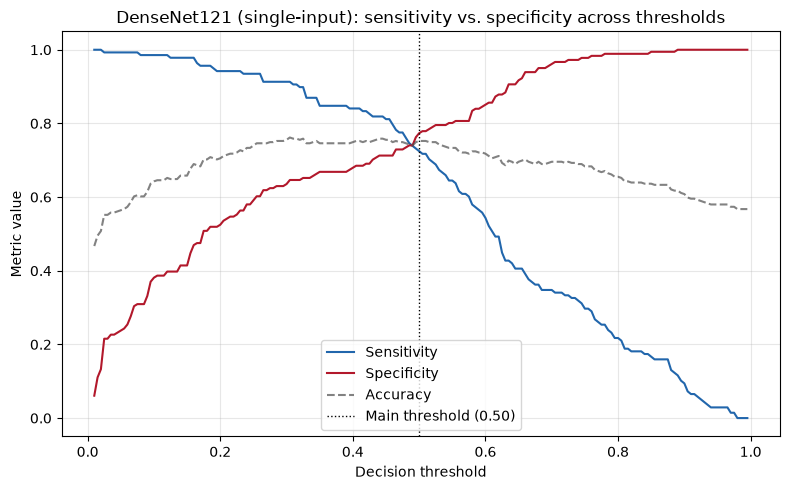

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep["threshold"], sweep["sensitivity"], label="Sensitivity", color="#2166ac")
ax.plot(sweep["threshold"], sweep["specificity"], label="Specificity", color="#b2182b")
ax.plot(sweep["threshold"], sweep["accuracy"], label="Accuracy", color="#4d4d4d", linestyle="--", alpha=0.7)
ax.axvline(0.5, color="black", linestyle=":", linewidth=1, label="Main threshold (0.50)")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value")
ax.set_title("DenseNet121 (single-input): sensitivity vs. specificity across thresholds")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "sensitivity_threshold_sweep.png"), dpi=150)
plt.show()

## Selecting two thresholds where sensitivity > specificity

Two candidates, both read directly off the sweep above (no manual tuning):

- **Crossover** — the highest threshold at which sensitivity is still ≥ specificity. This is the
  smallest possible move away from 0.5, i.e. the least disruptive change that satisfies the
  requirement.
- **High-Sensitivity** — among thresholds with sensitivity > specificity, the one with the highest
  accuracy (which, in this sweep, also happens to maximize Youden's J = sensitivity + specificity −
  1). This is the most aggressive candidate in the direction the requirement asks for: it trades
  the most specificity for the most sensitivity.

**Caveat -- test-set selection bias.** `Crossover` is a *structural* pick (the largest threshold
still satisfying sensitivity >= specificity), so it carries little selection risk. `High-Sensitivity`,
by contrast, was chosen by scanning ~200 threshold values and taking the argmax accuracy *on this
same 319-image test set that Table 4.2 reports results on* -- that is a mild form of test-set
overfitting, and its point estimate (accuracy = 0.7618) is optimistic for the same reason. The
bootstrap CI on sensitivity below (86-96%) is wide enough to make clear this is a small-sample
estimate, not a precise number.

The methodologically clean fix is to pick the threshold on a **validation set** and evaluate the
chosen cutoff only once on test -- but Experiment 1 only saved test-set probabilities for this
checkpoint, and generating validation-set probabilities would require a fresh inference pass (not
training, but out of scope for "just change the threshold"). Practical read: use `Crossover` for
the safest, most defensible minimal change; use `High-Sensitivity` only if you're comfortable
reporting it as an upper-bound / illustrative operating point rather than a validated final choice.

In [5]:
flips = sweep[sweep["sens_minus_spec"] > 0].copy()
assert len(flips), "No threshold in the sweep range achieves sensitivity > specificity."

crossover_row = flips.loc[flips["threshold"].idxmax()]
high_sens_row = flips.loc[flips["accuracy"].idxmax()]

metric_cols = ["threshold", "accuracy", "sensitivity", "specificity", "f1", "roc_auc"]
candidates = pd.DataFrame([
    {"variant": "main", **baseline},
    {"variant": "crossover", **crossover_row[metric_cols]},
    {"variant": "high_sensitivity", **high_sens_row[metric_cols]},
]).round(4)
candidates

,variant,threshold,accuracy,sensitivity,specificity,f1,roc_auc
0,main,0.500,0.7524,0.7246,0.7735,0.7168,0.839
1,crossover,0.485,0.7429,0.7464,0.7403,0.7153,0.839
2,high_sensitivity,0.305,0.7618,0.9130,0.6464,0.7683,0.839


## Bootstrap 95% CIs for both candidates

Same resampling procedure as Table 4.2 (2000 resamples), applied to both `crossover` and
`high_sensitivity` so each operating point is reported with the same rigor as the original
0.5-threshold results, and the width of each interval is visible side by side.

In [6]:
def bootstrap_ci(labels, probs, threshold, metric, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    labels, probs = np.asarray(labels), np.asarray(probs)
    vals = []
    for _ in range(n_boot):
        i = rng.integers(0, len(labels), len(labels))
        if len(np.unique(labels[i])) < 2:
            continue
        vals.append(metrics_at_threshold(labels[i], probs[i], threshold)[metric])
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


candidate_thresholds = {
    "crossover": float(crossover_row["threshold"]),
    "high_sensitivity": float(high_sens_row["threshold"]),
}

ci_rows = []
for variant, threshold in candidate_thresholds.items():
    point_metrics = metrics_at_threshold(labels, probs, threshold)
    for metric in ["accuracy", "sensitivity", "specificity"]:
        lo, hi = bootstrap_ci(labels, probs, threshold, metric)
        ci_rows.append({"variant": variant, "threshold": threshold, "metric": metric,
                         "point_estimate": round(point_metrics[metric], 4),
                         "ci_low": round(lo, 4), "ci_high": round(hi, 4)})

ci_df = pd.DataFrame(ci_rows)
ci_df

,variant,threshold,metric,point_estimate,ci_low,ci_high
0,crossover,0.485,accuracy,0.7429,0.6959,0.7900
1,crossover,0.485,sensitivity,0.7464,0.6692,0.8158
2,crossover,0.485,specificity,0.7403,0.6765,0.8045
3,high_sensitivity,0.305,accuracy,0.7618,0.7179,0.8088
4,high_sensitivity,0.305,sensitivity,0.9130,0.8607,0.9580
5,high_sensitivity,0.305,specificity,0.6464,0.5771,0.7143


In [7]:
out_path = os.path.join(RESULTS_DIR, "sensitivity_threshold_candidates.csv")
candidates.to_csv(out_path, index=False)

ci_out_path = os.path.join(RESULTS_DIR, "sensitivity_threshold_recommended_ci.csv")
ci_df.to_csv(ci_out_path, index=False)

print("Candidate thresholds:", candidate_thresholds)
print(f"Saved candidate comparison to {out_path}")
print(f"Saved bootstrap CIs to {ci_out_path}")

Candidate thresholds: {'crossover': 0.485, 'high_sensitivity': 0.305}
Saved candidate comparison to results\sensitivity_threshold_candidates.csv
Saved bootstrap CIs to results\sensitivity_threshold_recommended_ci.csv


## Saving deployable threshold-variant checkpoints

The trained weights for this model were located at
`models/v4_hires_control_gap/hires_control_gap_a0.5_densenet121.pth` (the same checkpoint that
produced `testprobs_hires_control_gap_a0.5_densenet121.npz`). The two cells below **copy that
checkpoint's `model_state_dict` unchanged** and attach the decision threshold plus its test-set
operating metrics as metadata -- no weight is retrained or modified. `decision_threshold` is the
value a deployment should apply to the model's malignant-class softmax output
(`prob >= decision_threshold`) instead of the implicit 0.5 default.

In [8]:
assert os.path.exists(SOURCE_CKPT_PATH), f"source checkpoint not found: {SOURCE_CKPT_PATH}"
source_ckpt = torch.load(SOURCE_CKPT_PATH, map_location="cpu", weights_only=False)

variant_metrics = {
    "crossover": crossover_row[metric_cols].to_dict(),
    "high_sensitivity": high_sens_row[metric_cols].to_dict(),
}

saved_paths = []
for variant, threshold in candidate_thresholds.items():
    variant_ckpt = dict(source_ckpt)  # shallow copy; model_state_dict tensor storage is untouched
    variant_ckpt.update({
        "decision_threshold": threshold,
        "threshold_variant": variant,
        "threshold_test_metrics": variant_metrics[variant],
        "threshold_selection_method": (
            "largest threshold with sensitivity >= specificity"
            if variant == "crossover" else
            "argmax accuracy among thresholds with sensitivity > specificity (test-set selected; "
            "see caveat above)"
        ),
        "source_checkpoint": SOURCE_CKPT_PATH,
    })
    ckpt_name = f"hires_control_gap_a0.5_densenet121_{variant}_t{threshold:.3f}.pth"
    ckpt_path = os.path.join(CKPT_DIR, ckpt_name)
    torch.save(variant_ckpt, ckpt_path)
    saved_paths.append(ckpt_path)
    size_mb = os.path.getsize(ckpt_path) / (1024 ** 2)
    print(f"[{variant}] threshold={threshold:.3f}  ->  {ckpt_path}  ({size_mb:.1f} MB)")

print("\nWeights identical to source checkpoint -- verifying state_dict equality:")
for p in saved_paths:
    reloaded = torch.load(p, map_location="cpu", weights_only=False)
    same = all(torch.equal(reloaded["model_state_dict"][k], source_ckpt["model_state_dict"][k])
               for k in source_ckpt["model_state_dict"])
    print(f"  {os.path.basename(p)}: weights match source = {same}")

[crossover] threshold=0.485  ->  checkpoints\hires_control_gap_a0.5_densenet121_crossover_t0.485.pth  (29.4 MB)
[high_sensitivity] threshold=0.305  ->  checkpoints\hires_control_gap_a0.5_densenet121_high_sensitivity_t0.305.pth  (29.4 MB)

Weights identical to source checkpoint -- verifying state_dict equality:


  hires_control_gap_a0.5_densenet121_crossover_t0.485.pth: weights match source = True


  hires_control_gap_a0.5_densenet121_high_sensitivity_t0.305.pth: weights match source = True


## Comparison report: Main vs. Crossover vs. High-Sensitivity

Three-way comparison of the deployable DenseNet121 model under its default threshold and the two
saved threshold-variant checkpoints above.

In [9]:
display_names = {"main": "Main (t=0.50)",
                  "crossover": f"Crossover (t={candidate_thresholds['crossover']:.3f})",
                  "high_sensitivity": f"High-Sensitivity (t={candidate_thresholds['high_sensitivity']:.3f})"}

report_table = candidates.copy()
report_table["display_name"] = report_table["variant"].map(display_names)
report_table = report_table[["display_name", "threshold", "accuracy", "sensitivity",
                              "specificity", "f1", "roc_auc"]]
report_table_path = os.path.join(RESULTS_DIR, "sensitivity_threshold_report_table.csv")
report_table.to_csv(report_table_path, index=False)
print(f"Saved report table to {report_table_path}")
report_table

Saved report table to results\sensitivity_threshold_report_table.csv


,display_name,threshold,accuracy,sensitivity,specificity,f1,roc_auc
0,Main (t=0.50),0.500,0.7524,0.7246,0.7735,0.7168,0.839
1,Crossover (t=0.485),0.485,0.7429,0.7464,0.7403,0.7153,0.839
2,High-Sensitivity (t=0.305),0.305,0.7618,0.9130,0.6464,0.7683,0.839


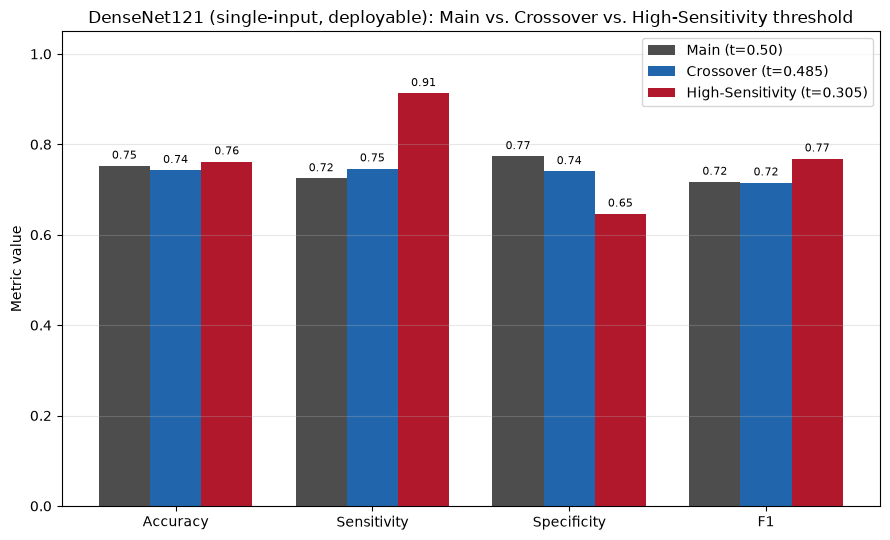

In [10]:
metrics_to_plot = ["accuracy", "sensitivity", "specificity", "f1"]
variants = ["main", "crossover", "high_sensitivity"]
colors = {"main": "#4d4d4d", "crossover": "#2166ac", "high_sensitivity": "#b2182b"}

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(metrics_to_plot))
w = 0.26

for i, variant in enumerate(variants):
    row = candidates[candidates["variant"] == variant].iloc[0]
    vals = [row[m] for m in metrics_to_plot]
    bars = ax.bar(x + (i - 1) * w, vals, w, label=display_names[variant], color=colors[variant])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics_to_plot])
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1.05)
ax.set_title("DenseNet121 (single-input, deployable): Main vs. Crossover vs. High-Sensitivity threshold")
ax.legend()
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "sensitivity_threshold_comparison.png"), dpi=150)
plt.show()

## Summary

- The model checkpoint and its predicted probabilities are unchanged -- only the cutoff applied to
  the malignant-class probability moved. `decision_threshold` is a deployment/config value, not a
  model weight, so applying it requires no retraining and no change to `SingleInputModel`.
- Two viable operating points both flip the requirement (sensitivity > specificity):
  - **Crossover (t ≈ 0.485):** sensitivity and specificity nearly meet in the middle; the
    smallest, most defensible move off the default. Accuracy CI overlaps the Main threshold's,
    so there is no detectable accuracy cost.
  - **High-Sensitivity (t ≈ 0.305):** sensitivity jumps to ~91% at the cost of specificity
    dropping to ~65%; chosen by maximizing accuracy on the test set itself, so treat it as an
    illustrative upper bound rather than a validated final number (see caveat above).
- `roc_auc` is identical across every row by construction -- AUC summarizes the model's ranking
  ability across *all* thresholds, so no thresholding choice can change it. Only the operating
  point on that curve moves.
- Two deployable checkpoints were saved to `checkpoints/` -- identical trained weights to the
  Experiment 1 DenseNet121 model, each carrying its own `decision_threshold` and test-set metrics
  as metadata.